In [1]:
import pandas as pd
import numpy as nm
import matplotlib.pyplot as plt
import seaborn as sn

## **Data Exploring and Cleaning**


> Check for Missing Values

> Check for imputation methods





In [2]:
pd.read_csv("/content/german_credit_data.csv")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [3]:
df = pd.read_csv("/content/german_credit_data.csv")
print("--- DataFrame Information ---")
df.info()
print("\n--- Missing Values (NaN) Count per Column ---")
print(df.isnull().sum())

--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB

--- Missing Values (NaN) Count per Column ---
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394


In [4]:
selected_columns = ['Age', 'Credit amount', 'Duration']
display(df[selected_columns].describe())

,Age,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000
std,11.375469,2822.736876,12.058814
min,19.000000,250.000000,4.000000
25%,27.000000,1365.500000,12.000000
50%,33.000000,2319.500000,18.000000
75%,42.000000,3972.250000,24.000000
max,75.000000,18424.000000,72.000000


In [5]:
print("Unique values in 'Checking account' column:")
display(df['Checking account'].unique())

Unique values in 'Checking account' column:


array(['little', 'moderate', nan, 'rich'], dtype=object)

In [6]:
print("Mode of 'Checking account' column:")
display(df['Checking account'].mode())

Mode of 'Checking account' column:


,Checking account
0,little


In [7]:
df['Checking account'].fillna('little', inplace=True)

print("--- DataFrame Information After Imputation ---")
df.info()
print("\n--- Missing Values (NaN) Count per Column After Imputation ---")
print(df.isnull().sum())

--- DataFrame Information After Imputation ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  1000 non-null   object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB

--- Missing Values (NaN) Count per Column After Imputation ---
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving account

/tmp/ipykernel_23519/99420473.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Checking account'].fillna('little', inplace=True)


In [8]:
df.dropna(subset=['Saving accounts'], inplace=True)

print("--- DataFrame Information After Dropping Rows with Missing Saving Accounts ---")
df.info()
print("\n--- Missing Values (NaN) Count per Column After Dropping Rows ---")
print(df.isnull().sum())

--- DataFrame Information After Dropping Rows with Missing Saving Accounts ---
<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 1 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        817 non-null    int64 
 1   Age               817 non-null    int64 
 2   Sex               817 non-null    object
 3   Job               817 non-null    int64 
 4   Housing           817 non-null    object
 5   Saving accounts   817 non-null    object
 6   Checking account  817 non-null    object
 7   Credit amount     817 non-null    int64 
 8   Duration          817 non-null    int64 
 9   Purpose           817 non-null    object
 10  Risk              817 non-null    object
dtypes: int64(5), object(6)
memory usage: 76.6+ KB

--- Missing Values (NaN) Count per Column After Dropping Rows ---
Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing          

### **Uni Variate Analysis for Data**

In [9]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,little,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
6,6,53,male,2,own,quite rich,little,2835,24,furniture/equipment,good


/tmp/ipykernel_23519/3571895796.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Job', palette='viridis')


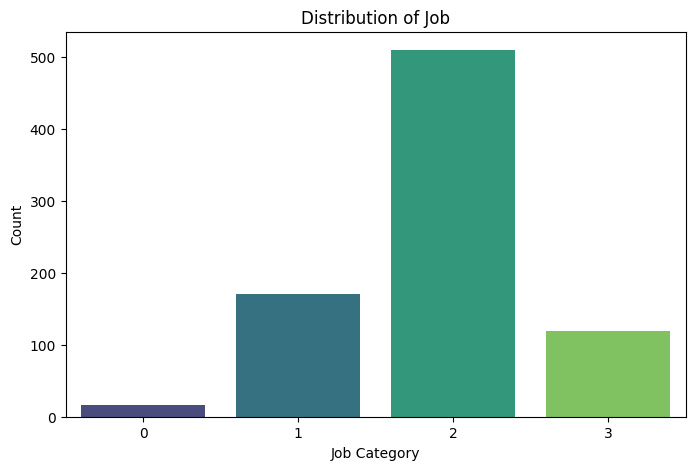

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar graph for 'Job' column
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Job', palette='viridis')
plt.title('Distribution of Job')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_23519/351952126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Housing', palette='plasma')


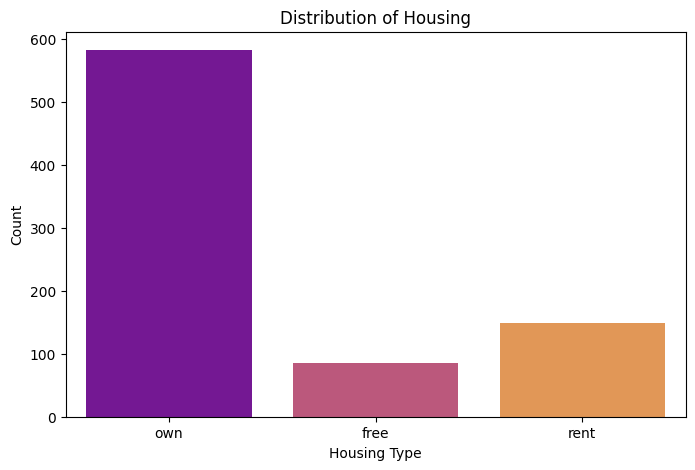

In [11]:
# Bar graph for 'Housing' column
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Housing', palette='plasma')
plt.title('Distribution of Housing')
plt.xlabel('Housing Type')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_23519/1860102079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Purpose', palette='cividis', order=df['Purpose'].value_counts().index)


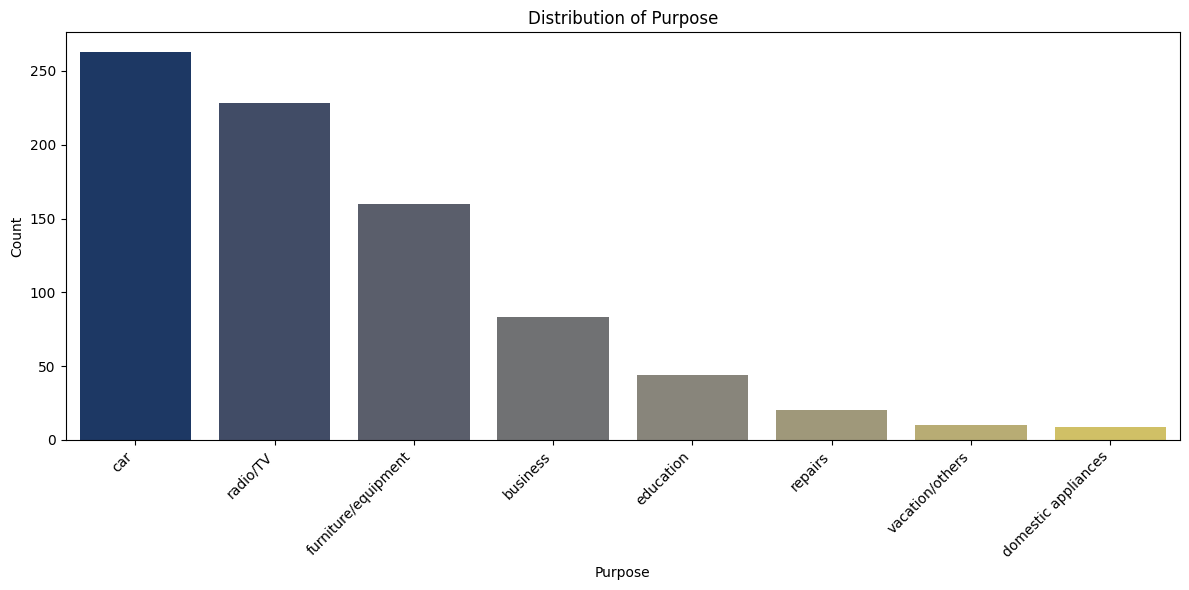

In [12]:
# Bar graph for 'Purpose' column
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Purpose', palette='cividis', order=df['Purpose'].value_counts().index)
plt.title('Distribution of Purpose')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
df.head(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,little,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
6,6,53,male,2,own,quite rich,little,2835,24,furniture/equipment,good
7,7,35,male,3,rent,little,moderate,6948,36,car,good
8,8,61,male,1,own,rich,little,3059,12,radio/TV,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad
10,10,25,female,2,rent,little,moderate,1295,12,car,bad
11,11,24,female,2,rent,little,little,4308,48,business,bad


/tmp/ipykernel_23519/2968296736.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Saving accounts', palette='cividis', order=df['Saving accounts'].value_counts().index)


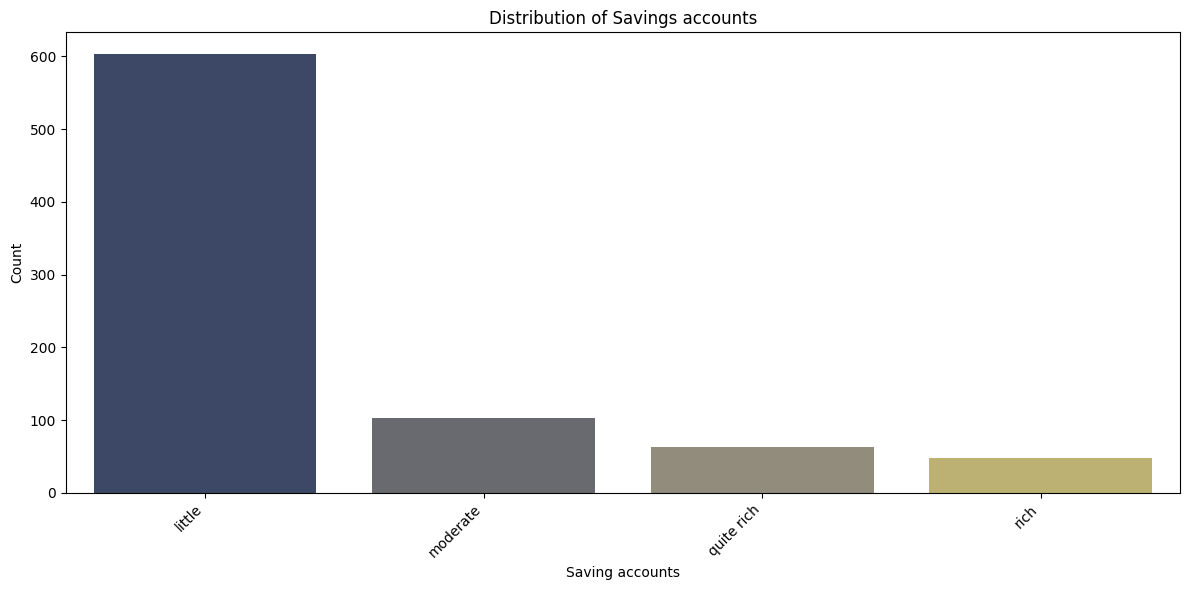

In [14]:
# Bar graph for 'Purpose' column
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Saving accounts', palette='cividis', order=df['Saving accounts'].value_counts().index)
plt.title('Distribution of Savings accounts')
plt.xlabel('Saving accounts')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_23519/785519141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk', palette='cividis', order=df['Risk'].value_counts().index)


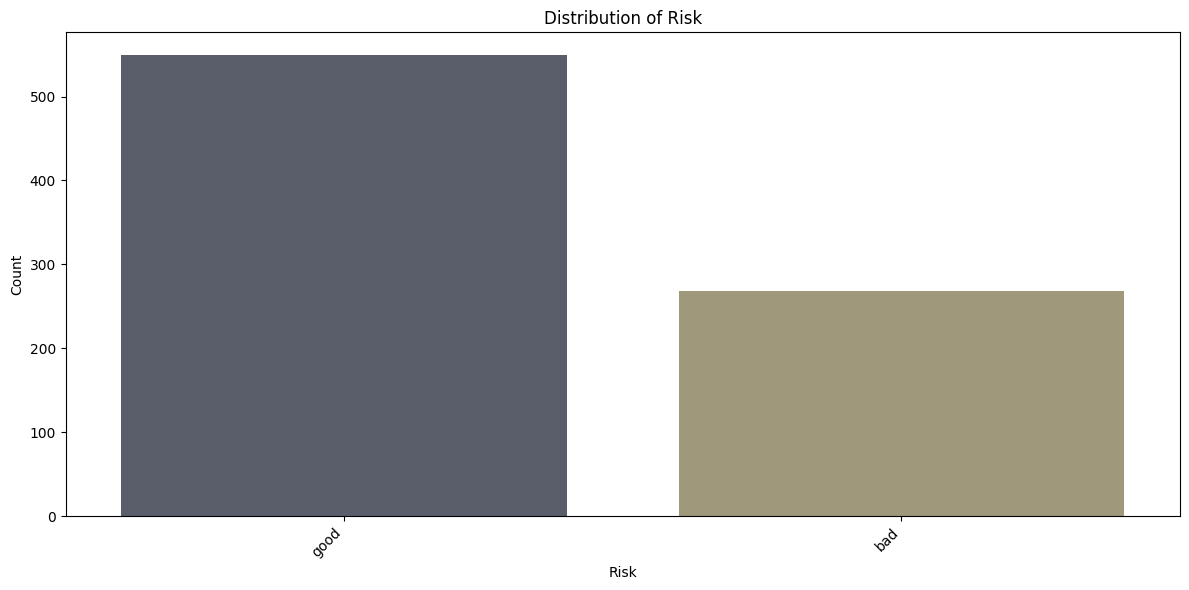

In [15]:
# Bar graph for 'Purpose' column
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Risk', palette='cividis', order=df['Risk'].value_counts().index)
plt.title('Distribution of Risk')
plt.xlabel('Risk')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
risk_counts = df['Risk'].value_counts()
display(risk_counts)

,count
Risk,
good,549
bad,268


### **Now we will do Bivariate analysis**

> Analysing relationship between 2 variables for understanding how the realtionship works



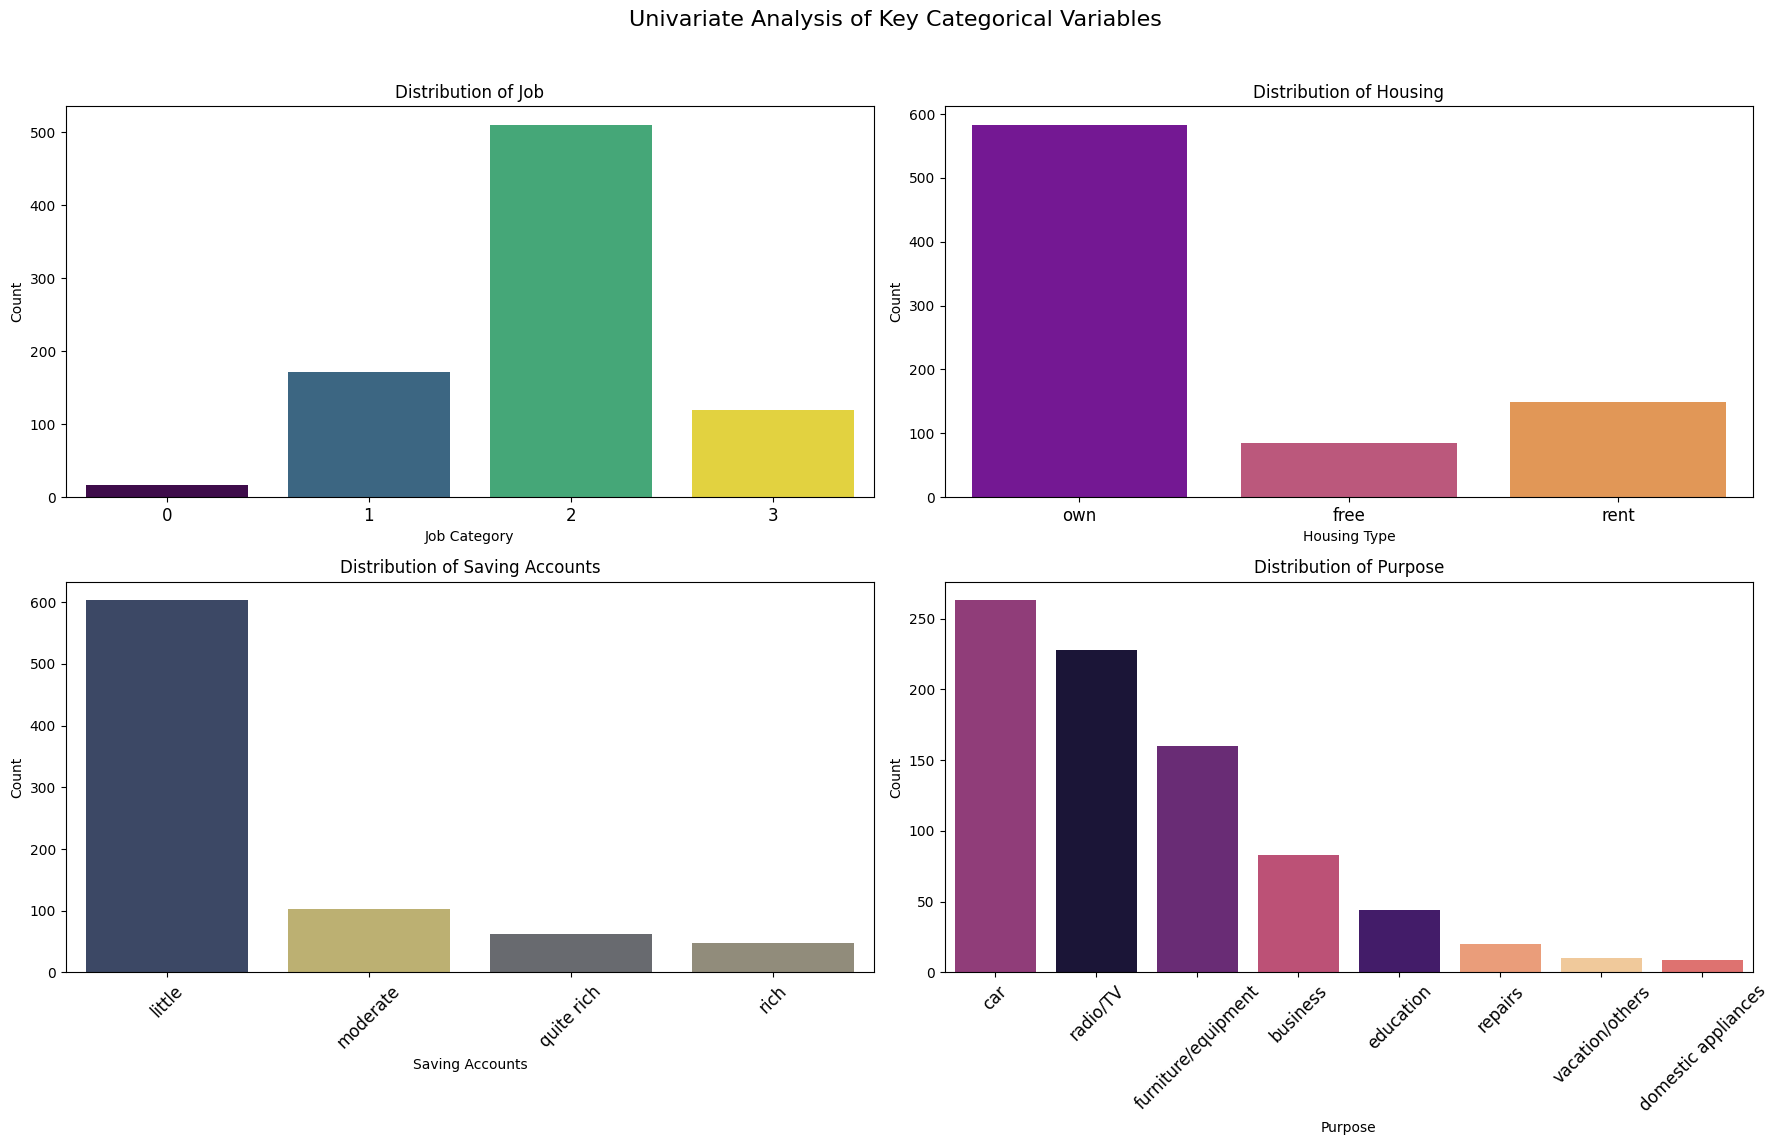

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.suptitle('Univariate Analysis of Key Categorical Variables', fontsize=16)

# Bar graph for 'Job' column
sns.countplot(data=df, x='Job', palette='viridis', ax=axes[0, 0], hue='Job', legend=False)
axes[0, 0].set_title('Distribution of Job')
axes[0, 0].set_xlabel('Job Category')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', labelsize=12)

# Bar graph for 'Housing' column
sns.countplot(data=df, x='Housing', palette='plasma', ax=axes[0, 1], hue='Housing', legend=False)
axes[0, 1].set_title('Distribution of Housing')
axes[0, 1].set_xlabel('Housing Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', labelsize=12)

# Bar graph for 'Saving accounts' column
sns.countplot(data=df, x='Saving accounts', palette='cividis', ax=axes[1, 0], hue='Saving accounts', legend=False, order=df['Saving accounts'].value_counts().index)
axes[1, 0].set_title('Distribution of Saving Accounts')
axes[1, 0].set_xlabel('Saving Accounts')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45, labelsize=12)

# Bar graph for 'Purpose' column
sns.countplot(data=df, x='Purpose', palette='magma', ax=axes[1, 1], hue='Purpose', legend=False, order=df['Purpose'].value_counts().index)
axes[1, 1].set_title('Distribution of Purpose')
axes[1, 1].set_xlabel('Purpose')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent overlap
plt.show()

/tmp/ipykernel_23519/1871944525.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Age', ax=axes[0], palette='viridis')
/tmp/ipykernel_23519/1871944525.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Credit amount', ax=axes[1], palette='plasma')
/tmp/ipykernel_23519/1871944525.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Duration', ax=axes[2], palette='cividis')


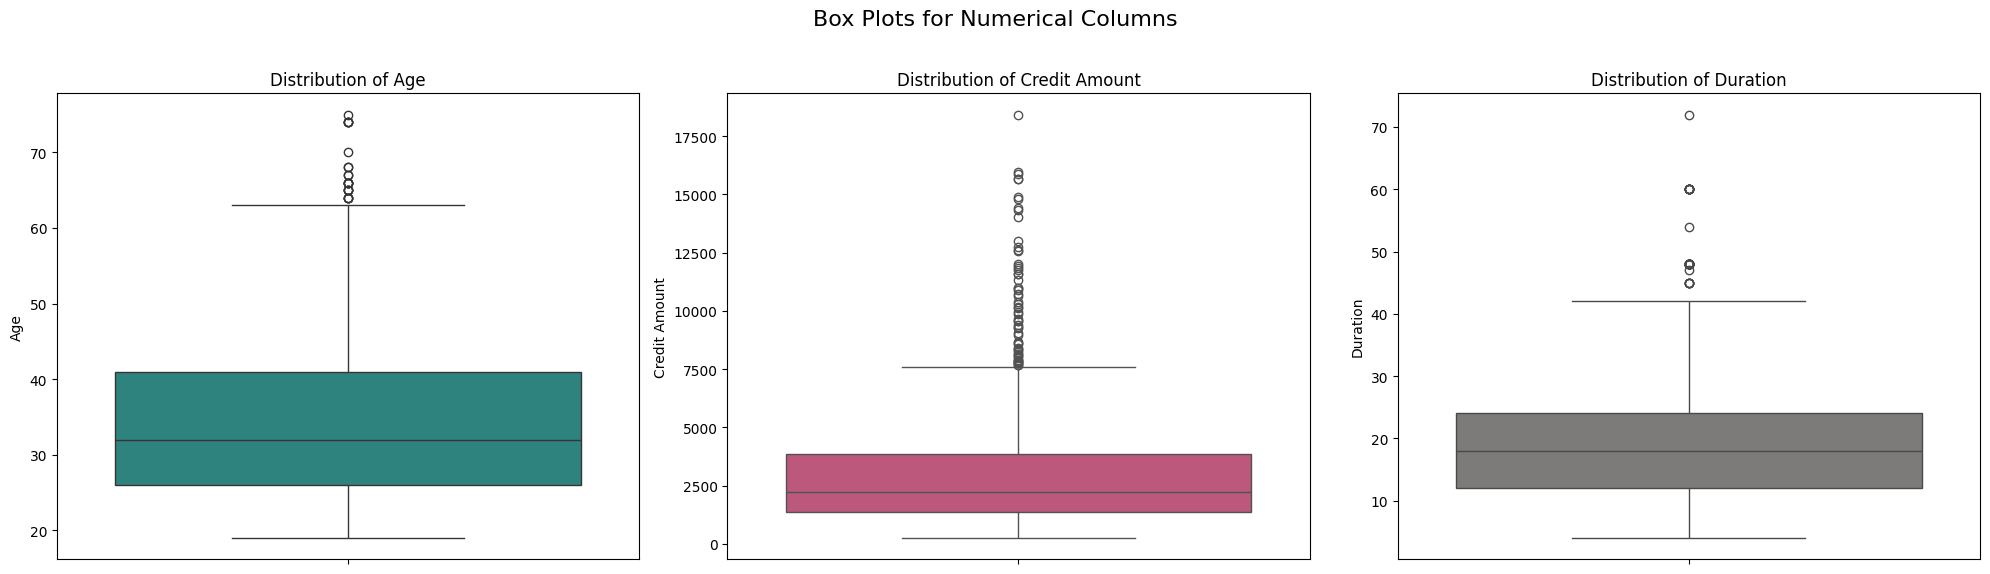

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots for the box plots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
fig.suptitle('Box Plots for Numerical Columns', fontsize=16)

# Box plot for 'Age'
sns.boxplot(data=df, y='Age', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Age')
axes[0].set_ylabel('Age')

# Box plot for 'Credit amount'
sns.boxplot(data=df, y='Credit amount', ax=axes[1], palette='plasma')
axes[1].set_title('Distribution of Credit Amount')
axes[1].set_ylabel('Credit Amount')

# Box plot for 'Duration'
sns.boxplot(data=df, y='Duration', ax=axes[2], palette='cividis')
axes[2].set_title('Distribution of Duration')
axes[2].set_ylabel('Duration')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent overlap
plt.show()

### What does a Box Plot Signify?

A **box plot** (or box-and-whisker plot) is a standardized way of displaying the distribution of data based on a five-number summary: the minimum, first quartile (Q1), median, third quartile (Q3), and maximum.

Here's what each part of the box plot represents:

*   **Median (the line inside the box)**: This is the middle value of the dataset, dividing the data into two equal halves. 50% of the data falls below the median and 50% above it.
*   **Box (the rectangular part)**: This represents the **Interquartile Range (IQR)**, which spans from the first quartile (Q1) to the third quartile (Q3). This box contains the middle 50% of the data.
    *   **First Quartile (Q1)**: 25% of the data falls below this value.
    *   **Third Quartile (Q3)**: 75% of the data falls below this value (or 25% falls above it).
*   **Whiskers (the lines extending from the box)**: These typically extend to the minimum and maximum values within 1.5 times the IQR from Q1 and Q3, respectively. They show the range of the majority of the data, excluding outliers.
*   **Outliers (individual points beyond the whiskers)**: These are data points that fall outside the range of the whiskers, indicating values that are unusually high or low compared to the rest of the dataset. They are often plotted as individual dots or asterisks.

**In summary, a box plot helps to quickly visualize:**
*   The central tendency (median).
*   The spread or variability of the data (IQR and whisker length).
*   The skewness of the distribution (by comparing the position of the median within the box and the lengths of the whiskers).
*   The presence of potential outliers.

### **Bi -Variate Analysis**

> Understanding each paramter with target variable



In [19]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,little,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
6,6,53,male,2,own,quite rich,little,2835,24,furniture/equipment,good


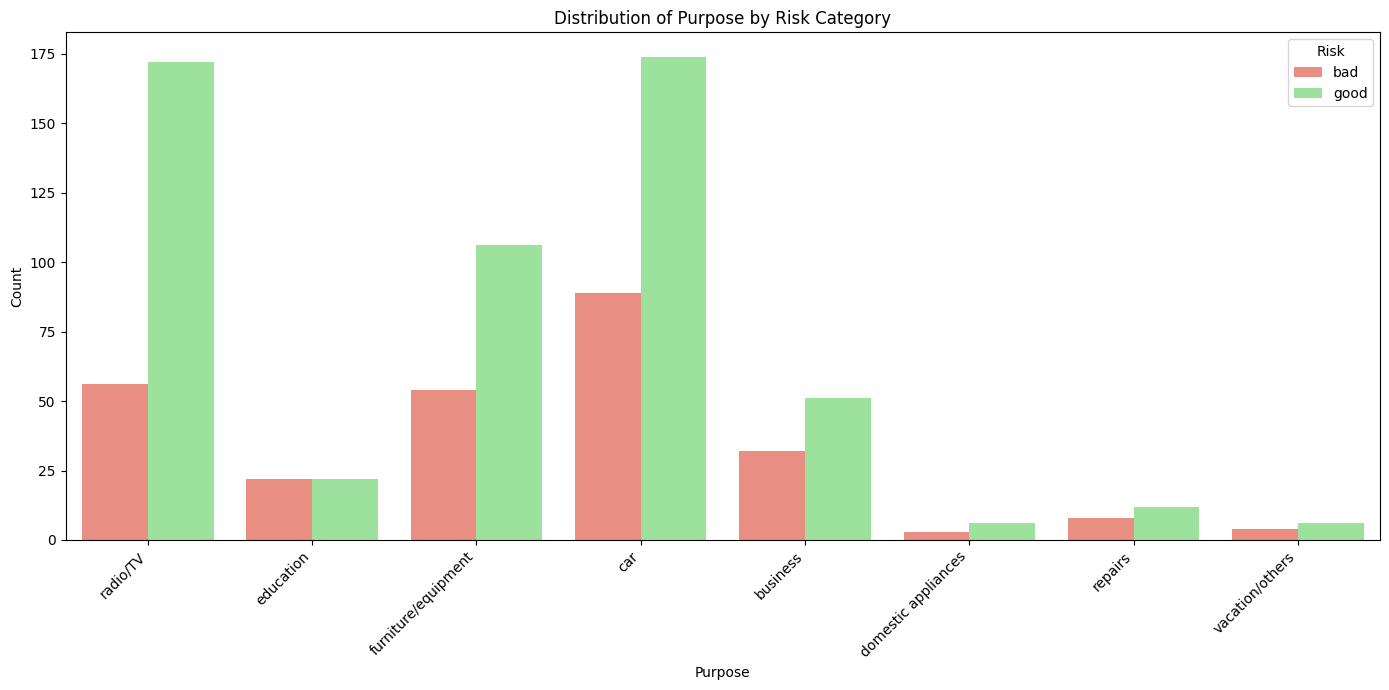

In [20]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='Purpose', hue='Risk', palette={'good': 'lightgreen', 'bad': 'salmon'})
plt.title('Distribution of Purpose by Risk Category')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

In [21]:
purpose_risk_pivot = pd.crosstab(df['Purpose'], df['Risk'], normalize='index') * 100
print('Percentage of Good vs Bad Loans for Each Purpose:')
display(purpose_risk_pivot.round(2))

Percentage of Good vs Bad Loans for Each Purpose:


Risk,bad,good
Purpose,,
business,38.55,61.45
car,33.84,66.16
domestic appliances,33.33,66.67
education,50.00,50.00
furniture/equipment,33.75,66.25
radio/TV,24.56,75.44
repairs,40.00,60.00
vacation/others,40.00,60.00


### Bivariate Analysis: Housing and Risk

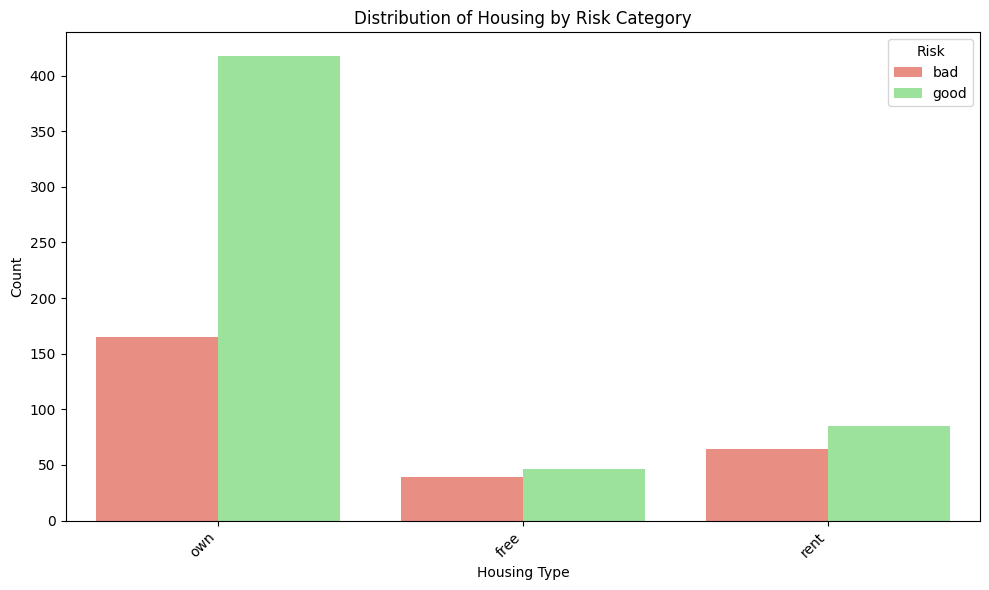

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Housing', hue='Risk', palette={'good': 'lightgreen', 'bad': 'salmon'})
plt.title('Distribution of Housing by Risk Category')
plt.xlabel('Housing Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

In [23]:
housing_risk_pivot = pd.crosstab(df['Housing'], df['Risk'], normalize='index') * 100
print('Percentage of Good vs Bad Loans for Each Housing Type:')
display(housing_risk_pivot.round(2))

Percentage of Good vs Bad Loans for Each Housing Type:


Risk,bad,good
Housing,,
free,45.88,54.12
own,28.30,71.70
rent,42.95,57.05


### Bivariate Analysis: Job and Risk

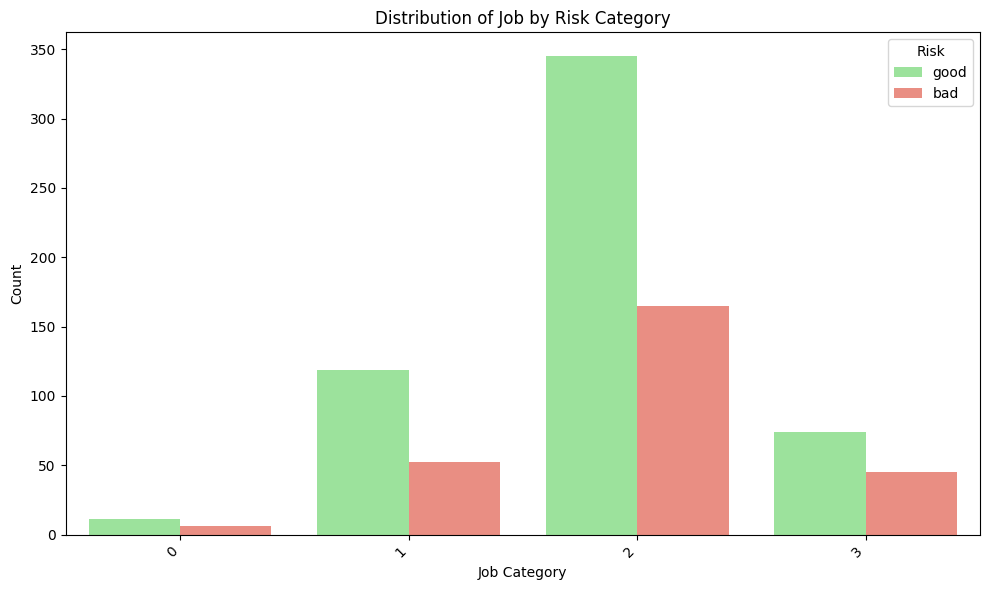

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Job', hue='Risk', palette={'good': 'lightgreen', 'bad': 'salmon'})
plt.title('Distribution of Job by Risk Category')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

In [25]:
job_risk_pivot = pd.crosstab(df['Job'], df['Risk'], normalize='index') * 100
print('Percentage of Good vs Bad Loans for Each Job Category:')
display(job_risk_pivot.round(2))

Percentage of Good vs Bad Loans for Each Job Category:


Risk,bad,good
Job,,
0,35.29,64.71
1,30.41,69.59
2,32.35,67.65
3,37.82,62.18


### Bivariate Analysis: Sex and Risk

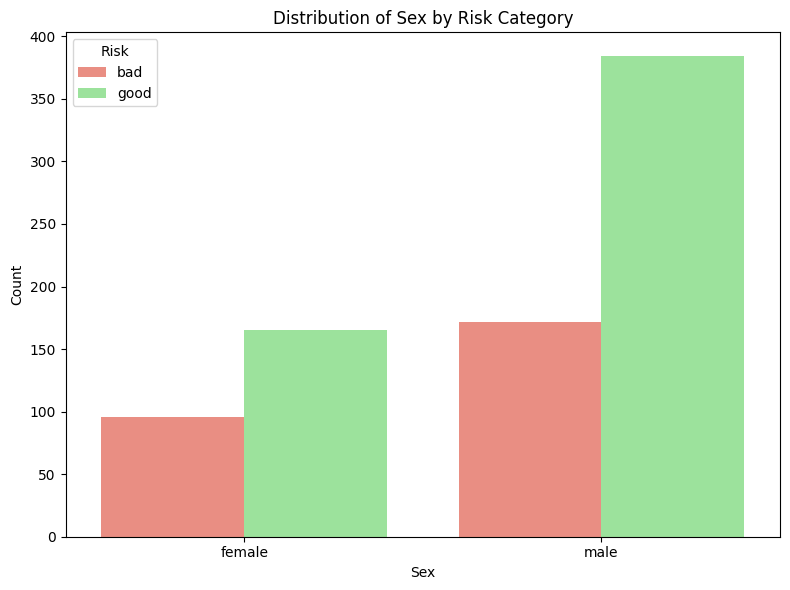

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Sex', hue='Risk', palette={'good': 'lightgreen', 'bad': 'salmon'})
plt.title('Distribution of Sex by Risk Category')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

In [27]:
sex_risk_pivot = pd.crosstab(df['Sex'], df['Risk'], normalize='index') * 100
print('Percentage of Good vs Bad Loans for Each Sex Category:')
display(sex_risk_pivot.round(2))

Percentage of Good vs Bad Loans for Each Sex Category:


Risk,bad,good
Sex,,
female,36.78,63.22
male,30.94,69.06


### Bivariate Analysis: Age and Risk (with Age Bins)

### Mean Credit Amount by Sex

In [28]:
mean_credit_by_sex = df.groupby('Sex')['Credit amount'].mean().reset_index()
print('Mean Credit Amount by Sex:')
display(mean_credit_by_sex.round(2))

Mean Credit Amount by Sex:


,Sex,Credit amount
0,female,2844.99
1,male,3262.31


### Mean Credit Amount by Housing

In [29]:
mean_credit_by_housing = df.groupby('Housing')['Credit amount'].mean().reset_index()
print('Mean Credit Amount by Housing:')
display(mean_credit_by_housing.round(2))

Mean Credit Amount by Housing:


,Housing,Credit amount
0,free,4495.60
1,own,2955.15
2,rent,3029.56


### Mean Credit Amount by Job

In [30]:
mean_credit_by_job = df.groupby('Job')['Credit amount'].mean().reset_index()
print('Mean Credit Amount by Job:')
display(mean_credit_by_job.round(2))

Mean Credit Amount by Job:


,Job,Credit amount
0,0,1614.47
1,1,2258.36
2,2,2986.33
3,3,5207.83


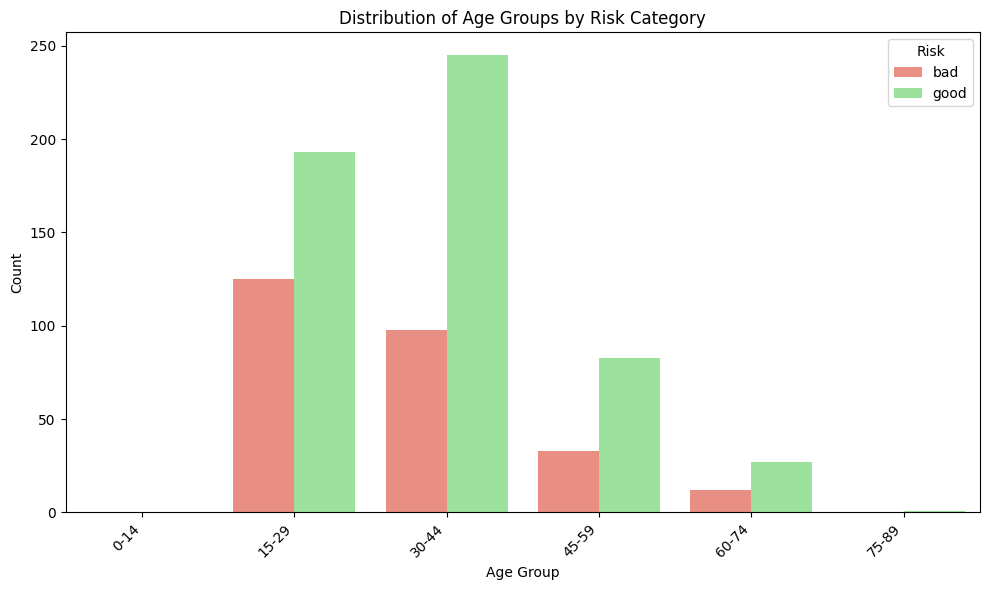

In [31]:
# Create age bins of 15
age_bins = [0, 15, 30, 45, 60, 75, 90]
age_labels = ['0-14', '15-29', '30-44', '45-59', '60-74', '75-89']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age_Group', hue='Risk', palette={'good': 'lightgreen', 'bad': 'salmon'})
plt.title('Distribution of Age Groups by Risk Category')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

In [32]:
age_risk_pivot = pd.crosstab(df['Age_Group'], df['Risk'], normalize='index') * 100
print('Percentage of Good vs Bad Loans for Each Age Group:')
display(age_risk_pivot.round(2))

Percentage of Good vs Bad Loans for Each Age Group:


Risk,bad,good
Age_Group,,
15-29,39.31,60.69
30-44,28.57,71.43
45-59,28.45,71.55
60-74,30.77,69.23
75-89,0.00,100.00


### Mean Credit Amount by Age Group

In [33]:
mean_credit_by_age_group = df.groupby('Age_Group')['Credit amount'].mean().reset_index()
print('Mean Credit Amount by Age Group:')
display(mean_credit_by_age_group.round(2))

Mean Credit Amount by Age Group:


/tmp/ipykernel_23519/702771748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_credit_by_age_group = df.groupby('Age_Group')['Credit amount'].mean().reset_index()


,Age_Group,Credit amount
0,0-14,NaN
1,15-29,3037.18
2,30-44,3248.69
3,45-59,3049.65
4,60-74,2971.49
5,75-89,6615.00


### Feature Engineering: Label Encoding Categorical Columns

In [34]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include=['object']).columns

# Create a dictionary to store the mappings for each column
encoded_mappings = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoded_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Label Encoding complete for categorical columns.")
print("\n--- Encoded Mappings ---")
for col, mapping in encoded_mappings.items():
    print(f"Column '{col}':")
    for original_val, encoded_val in mapping.items():
        print(f"  '{original_val}' -> {encoded_val}")
    print()

# Display the first few rows of the DataFrame with encoded values
print("--- DataFrame after Label Encoding ---")
display(df.head())

Label Encoding complete for categorical columns.

--- Encoded Mappings ---
Column 'Sex':
  'female' -> 0
  'male' -> 1

Column 'Housing':
  'free' -> 0
  'own' -> 1
  'rent' -> 2

Column 'Saving accounts':
  'little' -> 0
  'moderate' -> 1
  'quite rich' -> 2
  'rich' -> 3

Column 'Checking account':
  'little' -> 0
  'moderate' -> 1
  'rich' -> 2

Column 'Purpose':
  'business' -> 0
  'car' -> 1
  'domestic appliances' -> 2
  'education' -> 3
  'furniture/equipment' -> 4
  'radio/TV' -> 5
  'repairs' -> 6
  'vacation/others' -> 7

Column 'Risk':
  'bad' -> 0
  'good' -> 1

--- DataFrame after Label Encoding ---


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Age_Group
1,1,22,0,2,1,0,1,5951,48,5,0,15-29
2,2,49,1,1,1,0,0,2096,12,3,1,45-59
3,3,45,1,2,0,0,0,7882,42,4,1,45-59
4,4,53,1,2,0,0,0,4870,24,1,0,45-59
6,6,53,1,2,1,2,0,2835,24,4,1,45-59


In [35]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("Column 'Unnamed: 0' dropped successfully.")
else:
    print("Column 'Unnamed: 0' not found in DataFrame.")

print("--- DataFrame after dropping 'Unnamed: 0' ---")
display(df.head())

Column 'Unnamed: 0' dropped successfully.
--- DataFrame after dropping 'Unnamed: 0' ---


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Age_Group
1,22,0,2,1,0,1,5951,48,5,0,15-29
2,49,1,1,1,0,0,2096,12,3,1,45-59
3,45,1,2,0,0,0,7882,42,4,1,45-59
4,53,1,2,0,0,0,4870,24,1,0,45-59
6,53,1,2,1,2,0,2835,24,4,1,45-59


### Correlation Matrix of Numeric Features

In [36]:
import numpy as np

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Apply the mask to the correlation matrix, setting upper triangle values to NaN
correlation_matrix_masked = correlation_matrix.mask(mask)

print("Correlation Matrix (Lower Triangle Only):")
display(correlation_matrix_masked.round(2))

Correlation Matrix (Lower Triangle Only):


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,-0.02,0.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Housing,-0.31,-0.19,-0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,0.04,-0.01,-0.03,0.04,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,-0.01,-0.02,-0.03,-0.01,0.01,NaN,NaN,NaN,NaN,NaN
Credit amount,0.03,0.07,0.31,-0.11,-0.06,0.02,NaN,NaN,NaN,NaN
Duration,-0.05,0.07,0.22,-0.13,-0.03,0.01,0.63,NaN,NaN,NaN
Purpose,-0.08,-0.07,-0.01,0.02,-0.04,-0.00,-0.12,-0.08,NaN,NaN
Risk,0.08,0.06,-0.04,-0.02,0.15,-0.06,-0.19,-0.27,0.06,NaN


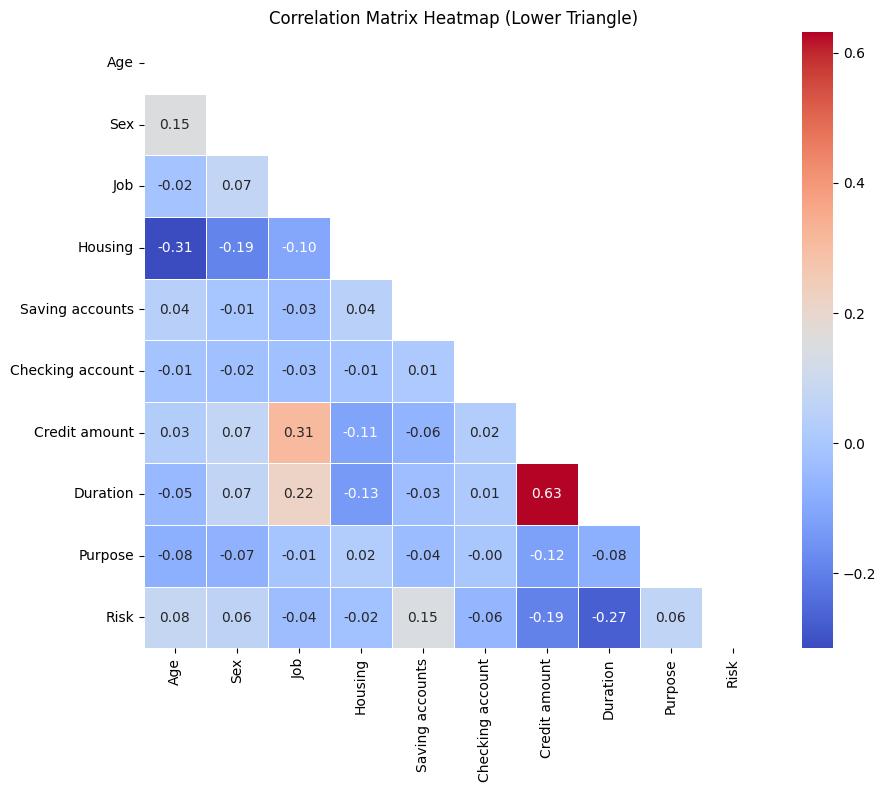

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_masked, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap (Lower Triangle)')
plt.show()

### **Importing train - test split model to train and build the model**


1.   Split the data
2.   Train the model



In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X = df.drop(['Risk', 'Age_Group'], axis=1)
y = df['Risk']

Now, we'll split the data into training and testing sets using a 70-30 ratio. `X_train` and `y_train` will contain 70% of the data for training the model, while `X_test` and `y_test` will contain the remaining 30% for evaluating its performance. A `random_state` is set for reproducibility.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (571, 9)
Shape of X_test: (246, 9)
Shape of y_train: (571,)
Shape of y_test: (246,)


# **Model Training and Evaluation**

We will now train several classification models and evaluate their performance based on accuracy.

In [41]:
# 1. Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)        # learns the relationship between parameters in X_Ttain against their Output Y_train

y_pred_log_reg = log_reg_model.predict(X_test)             # Model tries to predict on unseen data in X_test
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)    # Compares Model Prediction against Actual results in Y_test

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")

Logistic Regression Accuracy: 0.7480


In [42]:
# 2. Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)
y_pred_dec_tree = dec_tree_model.predict(X_test)
accuracy_dec_tree = accuracy_score(y_test, y_pred_dec_tree)

print(f"Decision Tree Accuracy: {accuracy_dec_tree:.4f}")

Decision Tree Accuracy: 0.6098


In [43]:
# 3. XGBoost Classifier
import xgboost as xgb

xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Suppress warning for use_label_encoder
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:41:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.6829


In [44]:
# 4. Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Accuracy: 0.7276
